'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


D:\jupyterrrrr\AAAsindy批发\real_condition_test_comparison.pdf
D:\jupyterrrrr\AAAsindy批发\real_condition_test_comparison.png


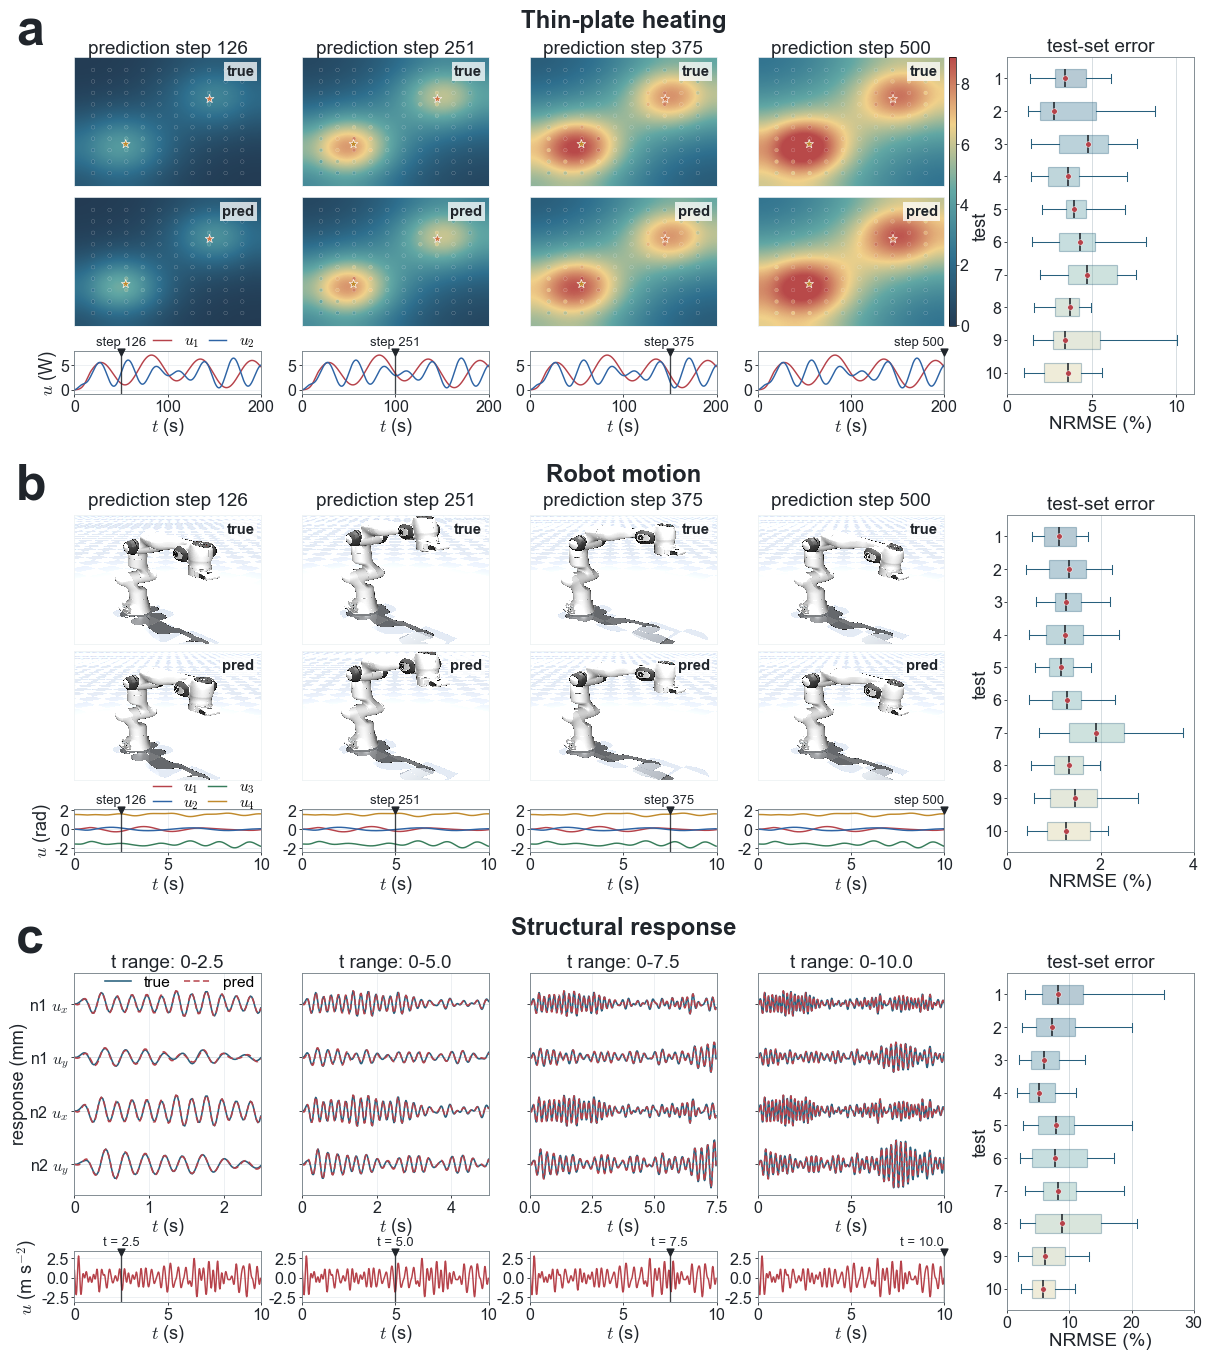

In [2]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib as mpl

IN_NOTEBOOK = "ipykernel" in sys.modules
if IN_NOTEBOOK:
    try:
        get_ipython().run_line_magic("matplotlib", "inline")  # type: ignore[name-defined]
    except Exception:
        pass
else:
    mpl.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as pe
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap, PowerNorm
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.ticker import MaxNLocator
from PIL import Image, ImageFilter
from scipy.optimize import least_squares


BASE_DIR = Path(r"C:\Users\HP\Desktop\test1+test2")
try:
    OUTPUT_DIR = Path(__file__).resolve().parent
except NameError:
    OUTPUT_DIR = Path.cwd()
PDF_PATH = OUTPUT_DIR / "real_condition_test_comparison.pdf"
PNG_PATH = OUTPUT_DIR / "real_condition_test_comparison.png"
CACHE_DIR = OUTPUT_DIR / "real_condition_cache"

PANDA_REF_DIR = Path(r"D:\FLARE\test files\panda")
sys.path.insert(0, str(PANDA_REF_DIR))
import render_panda_offline_comparison as panda_ref  # noqa: E402


SHEET_NPZ = (
    BASE_DIR
    / "AAAsheet"
    / "outputs"
    / "offline_encoder_rollout_tabular_window_sindy_2026_06_22_22_48_51_best"
    / "offline_prediction_sheet_test_000.npz"
)
ROBOT_NPZ = (
    BASE_DIR
    / "AAArobot"
    / "outputs"
    / "offline_encoder_rollout_tabular_window_sindy_2026_05_31_20_22_30_best"
    / "offline_prediction_panda_test_traj_000.npz"
)
ROBOT_TEST = BASE_DIR / "AAArobot" / "test" / "panda_test_traj_000.npy"
AGG_NPZ = (
    BASE_DIR
    / "AAAagg"
    / "outputs"
    / "offline_encoder_rollout_tabular_window_sindy_2026_06_03_20_46_56_best"
    / "offline_prediction_boucwen_test_000.npz"
)
AGG_PARAMS = BASE_DIR / "AAAagg" / "outputs" / "tabular_window_sindy_2026_06_03_20_46_56_params.json"

PLATE_LX = 0.20
PLATE_LY = 0.20
SENSOR_MARGIN = 0.02
HEATER_POSITIONS = np.asarray([[0.055, 0.065], [0.145, 0.135]], dtype=float)

FIGURE_SIZE = (12.0, 14.0)
FIGURE_MARGINS = dict(left=0.050, right=0.982, top=0.940, bottom=0.045)
OUTER_HSPACE = 0.36
PANEL_WIDTH_FACTOR = 0.90
TITLE_SIZE = 16.2
SUBTITLE_SIZE = 13.6
LABEL_SIZE = 13.0
TICK_SIZE = 11.6
LEGEND_SIZE = 11.2
ROW_LABEL_SIZE = 36

TEXT_COLOR = "#20252B"
GRID_COLOR = "#DCE3E8"
SPINE_COLOR = "#7A858C"
TRACK_BLUE = "#28607D"
PRED_BLUE = "#4B7EA1"
ACCENT_RED = "#B6424A"
ACCENT_GREEN = "#377D5B"
ACCENT_GOLD = "#C08A2C"
FORCE_COLORS = [ACCENT_RED, "#2E64A5", ACCENT_GREEN, ACCENT_GOLD]

FIELD_CMAP = LinearSegmentedColormap.from_list(
    "paper_thermal",
    ["#233B53", "#2E6F8E", "#61A7A4", "#F1D18A", "#B84949"],
)
SURFACE_CMAP = LinearSegmentedColormap.from_list(
    "paper_surface",
    ["#174563", "#24799B", "#67B1A5", "#E6C47A"],
)
ERROR_CMAP = LinearSegmentedColormap.from_list(
    "paper_error",
    ["#F7F8F6", "#E8C978", "#B6424A"],
)

TIME_FRACTIONS = [0.25, 0.50, 0.75, 1.00]


def configure_mpl() -> None:
    mpl.rcParams.update(
        {
            "font.family": "Arial",
            "font.size": TICK_SIZE,
            "axes.linewidth": 0.65,
            "axes.labelcolor": TEXT_COLOR,
            "xtick.color": TEXT_COLOR,
            "ytick.color": TEXT_COLOR,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "mathtext.fontset": "cm",
            "axes.unicode_minus": False,
        }
    )


def load_dict_npy(path: Path) -> dict:
    arr = np.load(path, allow_pickle=True)
    if isinstance(arr, np.ndarray) and arr.shape == ():
        return arr.item()
    raise ValueError(f"Expected scalar dict npy: {path}")


def time_indices(length: int) -> list[int]:
    return [int(round(frac * (length - 1))) for frac in TIME_FRACTIONS]


def style_axis(ax: plt.Axes, grid: bool = True) -> None:
    ax.tick_params(axis="both", labelsize=TICK_SIZE, length=2.5, width=0.6, colors=TEXT_COLOR, pad=1.5)
    for spine in ax.spines.values():
        spine.set_linewidth(0.65)
        spine.set_color(SPINE_COLOR)
    if grid:
        ax.grid(True, color=GRID_COLOR, linewidth=0.45, alpha=0.8)


def add_panel_badge(ax: plt.Axes, text: str) -> None:
    ax.text(
        0.965,
        0.94,
        text,
        transform=ax.transAxes,
        fontsize=10.6,
        fontweight="bold",
        color=TEXT_COLOR,
        ha="right",
        va="top",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.76, pad=1.8),
        zorder=10,
    )


def infer_square_grid(sensor_count: int) -> tuple[int, int]:
    side = int(round(np.sqrt(sensor_count)))
    if side * side != sensor_count:
        raise ValueError(f"Expected a square sensor grid, got {sensor_count}")
    return side, side


def sheet_field(values: np.ndarray, nx: int, ny: int) -> np.ndarray:
    return np.asarray(values, dtype=float).reshape(ny, nx)


def draw_sheet_map(
    ax: plt.Axes,
    values: np.ndarray,
    nx: int,
    ny: int,
    vmin: float,
    vmax: float,
    title: str | None = None,
) -> mpl.image.AxesImage:
    image = ax.imshow(
        sheet_field(values, nx, ny),
        origin="lower",
        extent=(0.0, PLATE_LX, 0.0, PLATE_LY),
        cmap=FIELD_CMAP,
        vmin=vmin,
        vmax=vmax,
        interpolation="bicubic",
        aspect="auto",
    )
    sensor_x = np.linspace(SENSOR_MARGIN, PLATE_LX - SENSOR_MARGIN, nx)
    sensor_y = np.linspace(SENSOR_MARGIN, PLATE_LY - SENSOR_MARGIN, ny)
    xs, ys = np.meshgrid(sensor_x, sensor_y, indexing="xy")
    ax.scatter(
        xs.ravel(),
        ys.ravel(),
        c=values,
        cmap=FIELD_CMAP,
        vmin=vmin,
        vmax=vmax,
        s=7.0,
        edgecolors="white",
        linewidths=0.12,
        alpha=0.85,
        zorder=3,
    )
    ax.scatter(
        HEATER_POSITIONS[:, 0],
        HEATER_POSITIONS[:, 1],
        marker="*",
        s=44,
        c=[ACCENT_GOLD, "#D07445"],
        edgecolors="white",
        linewidths=0.45,
        zorder=4,
    )
    ax.set_xlim(0.0, PLATE_LX)
    ax.set_ylim(0.0, PLATE_LY)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(0.6)
        spine.set_color("#EEF2F4")
    if title:
        ax.set_title(title, fontsize=SUBTITLE_SIZE, color=TEXT_COLOR, fontweight="normal", pad=2)
    return image


def draw_forcing(
    ax: plt.Axes,
    t: np.ndarray,
    forcing: np.ndarray,
    frame_idx: int | None,
    ylabel: str,
    labels: list[str] | None = None,
    legend: bool = False,
    step_label: str | None = None,
    legend_loc: str = "lower center",
    legend_bbox: tuple[float, float] = (0.5, 1.20),
    legend_ncol: int | None = None,
    legend_labelspacing: float = 0.3,
) -> None:
    forcing = np.asarray(forcing, dtype=float)
    if forcing.ndim == 1:
        forcing = forcing[:, None]
    for j in range(forcing.shape[1]):
        label = labels[j] if labels and j < len(labels) else rf"$u_{j + 1}$"
        ax.plot(t, forcing[:, j], color=FORCE_COLORS[j % len(FORCE_COLORS)], lw=1.05, label=label)
    ax.set_xlim(float(t[0]), float(t[-1]))
    finite = forcing[np.isfinite(forcing)]
    y_min, y_max = float(np.min(finite)), float(np.max(finite))
    pad = max(1e-9, 0.12 * (y_max - y_min))
    ax.set_ylim(y_min - pad, y_max + pad)
    if frame_idx is not None:
        current_t = float(t[frame_idx])
        top = y_max + 0.84 * pad
        text_ha = "right" if frame_idx >= int(0.92 * (len(t) - 1)) else "center"
        ax.axvline(current_t, color=TEXT_COLOR, lw=0.95, alpha=0.86, zorder=4)
        ax.scatter([current_t], [top], marker="v", s=24, color=TEXT_COLOR, zorder=5, clip_on=False)
        ax.text(
            current_t,
            top + 0.75 * pad,
            step_label or f"step {frame_idx + 1}",
            fontsize=9.4,
            color=TEXT_COLOR,
            ha=text_ha,
            va="bottom",
            clip_on=False,
        )
    ax.set_xlabel(r"$t$ (s)", fontsize=LABEL_SIZE, labelpad=0.5)
    ax.set_ylabel(ylabel, fontsize=LABEL_SIZE, labelpad=1.0)
    style_axis(ax)
    if legend:
        ax.legend(
            loc=legend_loc,
            bbox_to_anchor=legend_bbox,
            frameon=False,
            fontsize=LEGEND_SIZE,
            handlelength=1.15,
            borderaxespad=0.0,
            ncol=legend_ncol or min(4, forcing.shape[1]),
            columnspacing=0.6,
            labelspacing=legend_labelspacing,
        )


def prediction_error_distributions_percent(directory: Path, pattern: str) -> list[np.ndarray]:
    errors_by_test = []
    for path in sorted(directory.glob(pattern))[:10]:
        data = np.load(path, allow_pickle=True)
        p_true = np.asarray(data["p_true"], dtype=float)
        p_pred = np.asarray(data["p_pred"], dtype=float)
        err_norm = np.linalg.norm(p_pred - p_true, axis=1)
        denom = max(float(np.linalg.norm(p_true)) / np.sqrt(max(p_true.shape[0], 1)), 1e-12)
        errors_by_test.append(100.0 * err_norm / denom)
    if len(errors_by_test) != 10:
        raise ValueError(f"Expected 10 prediction files under {directory}, got {len(errors_by_test)}")
    return errors_by_test


def draw_error_boxplot(ax: plt.Axes, errors_by_test: list[np.ndarray]) -> None:
    positions = np.arange(len(errors_by_test), 0, -1, dtype=float)
    bp = ax.boxplot(
        errors_by_test,
        vert=False,
        positions=positions,
        widths=0.56,
        patch_artist=True,
        whis=(5, 95),
        showfliers=False,
        medianprops=dict(color=TEXT_COLOR, linewidth=1.15),
        boxprops=dict(facecolor="#DDEBE8", edgecolor=TRACK_BLUE, linewidth=0.85),
        whiskerprops=dict(color=TRACK_BLUE, linewidth=0.75),
        capprops=dict(color=TRACK_BLUE, linewidth=0.75),
    )
    for i, box in enumerate(bp["boxes"]):
        box.set_facecolor(FIELD_CMAP(0.20 + 0.055 * i))
        box.set_alpha(0.34)
    medians = np.asarray([np.median(v) for v in errors_by_test], dtype=float)
    ax.scatter(medians, positions, s=16, color=ACCENT_RED, edgecolors="white", linewidths=0.35, zorder=3)
    ax.set_yticks(positions)
    ax.set_yticklabels([str(i) for i in range(1, len(errors_by_test) + 1)], fontsize=TICK_SIZE - 1.2)
    ax.set_ylabel("test", fontsize=LABEL_SIZE, labelpad=-4)
    ax.set_xlabel("NRMSE (%)", fontsize=SUBTITLE_SIZE, labelpad=1)
    ax.set_title("test-set error", fontsize=SUBTITLE_SIZE, fontweight="normal", color=TEXT_COLOR, pad=4)
    all_errors = np.concatenate([np.asarray(v, dtype=float) for v in errors_by_test])
    xmax = max(float(np.nanpercentile(all_errors, 98.5)) * 1.22, 1e-6)
    ax.set_xlim(0.0, xmax)
    ax.set_ylim(0.35, len(errors_by_test) + 0.65)
    style_axis(ax, grid=True)
    ax.grid(True, color="#C9D2D8", linewidth=0.55, alpha=0.95)
    ax.grid(axis="y", visible=False)


def marker_world_coordinates(
    model,
    data,
    body_ids: list[int],
    local_markers: np.ndarray,
    qpos: np.ndarray,
) -> np.ndarray:
    data.qpos[:] = qpos
    data.qvel[:] = 0.0
    panda_ref.mujoco.mj_forward(model, data)
    coords = []
    for body_id in body_ids:
        pos = data.xpos[body_id].copy()
        rot = data.xmat[body_id].reshape(3, 3).copy()
        coords.append((pos[None, :] + local_markers @ rot.T).reshape(-1))
    return np.concatenate(coords, axis=0)


def fit_q_to_markers(
    model,
    data,
    body_ids: list[int],
    local_markers: np.ndarray,
    target_markers: np.ndarray,
    initial_q: np.ndarray,
) -> tuple[np.ndarray, float]:
    lower = model.jnt_range[:, 0].astype(float)
    upper = model.jnt_range[:, 1].astype(float)
    initial_q = np.clip(np.asarray(initial_q, dtype=float), lower + 1e-5, upper - 1e-5)
    target = np.asarray(target_markers, dtype=float).reshape(-1)

    def residual(q: np.ndarray) -> np.ndarray:
        return marker_world_coordinates(model, data, body_ids, local_markers, q) - target

    result = least_squares(
        residual,
        initial_q,
        bounds=(lower, upper),
        method="trf",
        max_nfev=100,
        ftol=1e-8,
        xtol=1e-8,
        gtol=1e-8,
    )
    rmse = float(np.sqrt(np.mean(result.fun**2)))
    return result.x.astype(float), rmse


def postprocess_robot_image(image: np.ndarray) -> np.ndarray:
    img = np.asarray(image, dtype=np.uint8)
    h, w = img.shape[:2]
    gray = img.mean(axis=2)
    yy = np.arange(h)[:, None]
    mask = (gray < 222) & (yy > 0.30 * h)
    ys, xs = np.where(mask)
    if xs.size > 0 and ys.size > 0:
        x0, x1 = int(xs.min()), int(xs.max())
        y0, y1 = int(ys.min()), int(ys.max())
        cx = 0.5 * (x0 + x1)
        cy = 0.5 * (y0 + y1)
        side = int(max(x1 - x0, y1 - y0) * 1.20)
        side = max(side, int(0.30 * min(h, w)))
        side = min(side, min(h, w))
        left = int(np.clip(cx - 0.5 * side, 0, w - side))
        top = int(np.clip(cy - 0.5 * side, 0, h - side))
        img = img[top : top + side, left : left + side].copy()

    img_float = img.astype(float)
    img_float = 1.02 * (img_float - 128.0) + 128.0
    cleaned = np.clip(img_float, 0, 255).astype(np.uint8)
    pil = Image.fromarray(cleaned)
    pil = pil.filter(ImageFilter.UnsharpMask(radius=0.9, percent=190, threshold=2))
    return np.asarray(pil)


def render_robot_snapshots(frame_indices: list[int]) -> tuple[list[np.ndarray], list[np.ndarray], list[float]]:
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    q_cache = CACHE_DIR / "panda_test_000_q_pred_fit_4frames.npz"

    offline = np.load(ROBOT_NPZ, allow_pickle=True)
    p_pred = np.asarray(offline["p_pred"], dtype=float)
    sample = load_dict_npy(ROBOT_TEST)
    true_q = np.asarray(sample["q"], dtype=float)
    link_names = [str(v) for v in sample["link_names"]]
    local_markers = np.asarray(sample["local_markers"], dtype=float)

    scene_xml = panda_ref.write_render_scene_xml()
    xml_text = scene_xml.read_text(encoding="utf-8")
    xml_text = xml_text.replace(
        '<global azimuth="135" elevation="-25"/>',
        '<global azimuth="135" elevation="-25" offwidth="1800" offheight="1800"/>',
    )
    scene_xml.write_text(xml_text, encoding="utf-8")
    model = panda_ref.mujoco.MjModel.from_xml_path(str(scene_xml))
    fit_data = panda_ref.mujoco.MjData(model)
    body_ids = [
        panda_ref.mujoco.mj_name2id(model, panda_ref.mujoco.mjtObj.mjOBJ_BODY, name)
        for name in link_names
    ]
    if any(body_id < 0 for body_id in body_ids):
        raise ValueError("One or more Panda link names were not found in the MuJoCo model.")

    if q_cache.exists():
        cache = np.load(q_cache)
        if np.array_equal(cache["frame_indices"], np.asarray(frame_indices, dtype=int)):
            q_pred = np.asarray(cache["q_pred"], dtype=float)
            rmse_values = [float(v) for v in cache["fit_rmse"]]
        else:
            q_pred = None
            rmse_values = []
    else:
        q_pred = None
        rmse_values = []

    if q_pred is None:
        q_pred_list = []
        for frame_idx in frame_indices:
            q_fit, rmse = fit_q_to_markers(
                model=model,
                data=fit_data,
                body_ids=body_ids,
                local_markers=local_markers,
                target_markers=p_pred[frame_idx],
                initial_q=true_q[frame_idx],
            )
            q_pred_list.append(q_fit)
            rmse_values.append(rmse)
        q_pred = np.stack(q_pred_list, axis=0)
        np.savez_compressed(
            q_cache,
            frame_indices=np.asarray(frame_indices, dtype=int),
            q_pred=q_pred,
            fit_rmse=np.asarray(rmse_values, dtype=float),
        )

    render_data_true = panda_ref.mujoco.MjData(model)
    render_data_pred = panda_ref.mujoco.MjData(model)
    renderer = panda_ref.mujoco.Renderer(model, height=1200, width=1200)
    camera = panda_ref.make_camera()
    camera.lookat[:] = [0.34, -0.02, 0.52]
    camera.distance = 1.30
    camera.azimuth = 134.0
    camera.elevation = -20.0
    option = panda_ref.make_scene_option()

    true_images = []
    pred_images = []
    for idx, frame_idx in enumerate(frame_indices):
        true_images.append(
            postprocess_robot_image(
                panda_ref.render_robot(model, render_data_true, renderer, camera, option, true_q[frame_idx])
            )
        )
        pred_images.append(
            postprocess_robot_image(
                panda_ref.render_robot(model, render_data_pred, renderer, camera, option, q_pred[idx])
            )
        )
    return true_images, pred_images, rmse_values


def draw_robot_image(ax: plt.Axes, image: np.ndarray, title: str | None = None) -> None:
    ax.imshow(image, interpolation="none", aspect="auto")
    ax.set_facecolor("#F7F8F5")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(0.6)
        spine.set_color("#EEF2F4")
    if title:
        ax.set_title(title, fontsize=SUBTITLE_SIZE, color=TEXT_COLOR, fontweight="normal", pad=7)


def shrink_axis_width(ax: plt.Axes, factor: float = 0.75) -> None:
    pos = ax.get_position()
    new_width = pos.width * factor
    ax.set_position([pos.x0 + 0.5 * (pos.width - new_width), pos.y0, new_width, pos.height])


def shrink_axis_height(ax: plt.Axes, factor: float = 0.45) -> None:
    pos = ax.get_position()
    new_height = pos.height * factor
    ax.set_position([pos.x0, pos.y0 + 0.5 * (pos.height - new_height), pos.width, new_height])


def shrink_axis_height_from_top(ax: plt.Axes, factor: float = 0.90) -> None:
    pos = ax.get_position()
    new_height = pos.height * factor
    ax.set_position([pos.x0, pos.y0 + (pos.height - new_height), pos.width, new_height])
def shift_axis(ax: plt.Axes, dx: float = 0.0, dy: float = 0.0) -> None:
    pos = ax.get_position()
    ax.set_position([pos.x0 + dx, pos.y0 + dy, pos.width, pos.height])


def apply_panel_width(ax: plt.Axes) -> None:
    shrink_axis_width(ax, factor=PANEL_WIDTH_FACTOR)

def agg_sensor_names() -> list[str]:
    params = json.loads(AGG_PARAMS.read_text(encoding="utf-8"))
    return [str(v) for v in params["sensor_names"]]


def pretty_agg_name(name: str) -> str:
    if name.startswith("node") and "_" in name:
        node, comp = name.split("_", 1)
        component = {"ux": r"u_x", "uy": r"u_y"}.get(comp, comp)
        node_id = str(int(node.replace("node", "")))
        return rf"n{node_id} ${component}$"
    return name


def draw_response_trace(
    ax: plt.Axes,
    t: np.ndarray,
    values: np.ndarray,
    color: str,
    title: str | None = None,
    badge: str | None = None,
    ylim: tuple[float, float] | None = None,
) -> None:
    ax.plot(t, values, color=color, lw=1.20)
    ax.axhline(0.0, color="#AEB8BC", lw=0.55, alpha=0.78, zorder=0)
    ax.set_xlim(float(t[0]), float(t[-1]))
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.set_ylabel("mm", fontsize=LABEL_SIZE, labelpad=1.0)
    style_axis(ax)
    if title:
        ax.set_title(title, fontsize=TITLE_SIZE, color=TEXT_COLOR, fontweight="normal", pad=2)
    if badge:
        add_panel_badge(ax, badge)


def draw_response_comparison(
    ax: plt.Axes,
    t: np.ndarray,
    true_values: np.ndarray,
    pred_values: np.ndarray,
    title: str,
    legend: bool = False,
) -> None:
    y_values = np.concatenate([true_values, pred_values])
    y_min = float(np.nanmin(y_values))
    y_max = float(np.nanmax(y_values))
    y_pad = max(1e-9, 0.12 * (y_max - y_min))
    ax.plot(t, true_values, color=TRACK_BLUE, lw=1.25, label="true")
    ax.plot(t, pred_values, color=ACCENT_RED, lw=1.20, ls=(0, (4.0, 2.2)), label="pred")
    ax.axhline(0.0, color="#AEB8BC", lw=0.55, alpha=0.78, zorder=0)
    ax.set_xlim(0.0, 10.0)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)
    ax.set_title(title, fontsize=SUBTITLE_SIZE, color=TEXT_COLOR, fontweight="normal", pad=12)
    ax.set_xlabel(r"$t$", fontsize=LABEL_SIZE, labelpad=0.5)
    ax.set_ylabel("mm", fontsize=LABEL_SIZE, labelpad=1.0)
    style_axis(ax)
    if legend:
        ax.legend(
            loc="lower right",
            bbox_to_anchor=(1.00, 1.04),
            frameon=False,
            fontsize=LEGEND_SIZE,
            handlelength=1.7,
            borderaxespad=0.0,
            ncol=2,
            columnspacing=0.9,
        )


def draw_response_window(
    ax: plt.Axes,
    t: np.ndarray,
    true_values: np.ndarray,
    pred_values: np.ndarray,
    end_idx: int,
    title: str,
    channel_labels: list[str],
    legend: bool = False,
) -> None:
    end_idx = int(np.clip(end_idx, 1, len(t) - 1))
    t_part = t[: end_idx + 1]
    true_part = true_values[: end_idx + 1]
    pred_part = pred_values[: end_idx + 1]
    n_channels = true_part.shape[1]
    amp = float(np.nanpercentile(np.abs(np.concatenate([true_values, pred_values], axis=0)), 99.0))
    amp = max(amp, 1e-9)
    spacing = 3.0 * amp
    offsets = spacing * np.arange(n_channels - 1, -1, -1, dtype=float)

    for j in range(n_channels):
        ax.plot(t_part, true_part[:, j] + offsets[j], color=TRACK_BLUE, lw=1.15, label="true" if j == 0 else None)
        ax.plot(
            t_part,
            pred_part[:, j] + offsets[j],
            color=ACCENT_RED,
            lw=1.10,
            ls=(0, (4.0, 2.2)),
            label="pred" if j == 0 else None,
        )
        ax.axhline(offsets[j], color="#D7DEE2", lw=0.45, zorder=0)

    ax.set_xlim(float(t[0]), float(t[end_idx]))
    ax.set_ylim(offsets[-1] - 1.7 * amp, offsets[0] + 1.7 * amp)
    ax.set_yticks(offsets)
    ax.set_yticklabels(channel_labels[:n_channels], fontsize=TICK_SIZE - 1.0)
    ax.set_title(title, fontsize=SUBTITLE_SIZE, color=TEXT_COLOR, fontweight="normal", pad=4)
    ax.set_xlabel(r"$t$ (s)", fontsize=LABEL_SIZE, labelpad=0.5)
    ax.set_ylabel("response (mm)", fontsize=LABEL_SIZE, labelpad=1.0)
    style_axis(ax)
    if legend:
        ax.legend(
            loc="upper right",
            bbox_to_anchor=(1.0, 1.02),
            frameon=False,
            fontsize=LEGEND_SIZE,
            handlelength=1.7,
            borderaxespad=0.0,
            ncol=2,
            columnspacing=0.9,
        )


def agg_magnitude(npz) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    params = json.loads(AGG_PARAMS.read_text(encoding="utf-8"))
    sensor_names = params["sensor_names"]
    node_ids = []
    ux_cols = []
    uy_cols = []
    for i, name in enumerate(sensor_names):
        if name.endswith("_ux"):
            node_ids.append(int(name[4:6]))
            ux_cols.append(i)
        elif name.endswith("_uy"):
            uy_cols.append(i)
    ux_cols = np.asarray(ux_cols, dtype=int)
    uy_cols = np.asarray(uy_cols, dtype=int)
    node_ids = np.asarray(node_ids, dtype=float)

    p_true = np.asarray(npz["p_true"], dtype=float)
    p_pred = np.asarray(npz["p_pred"], dtype=float)
    true_mag = 1000.0 * np.sqrt(p_true[:, ux_cols] ** 2 + p_true[:, uy_cols] ** 2)
    pred_mag = 1000.0 * np.sqrt(p_pred[:, ux_cols] ** 2 + p_pred[:, uy_cols] ** 2)
    error_mag = np.abs(pred_mag - true_mag)
    return node_ids, true_mag, pred_mag, error_mag


def agg_displacements(npz) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    params = json.loads(AGG_PARAMS.read_text(encoding="utf-8"))
    sensor_names = params["sensor_names"]
    ux_cols = []
    uy_cols = []
    for i, name in enumerate(sensor_names):
        if name.endswith("_ux"):
            ux_cols.append(i)
        elif name.endswith("_uy"):
            uy_cols.append(i)
    ux_cols = np.asarray(ux_cols, dtype=int)
    uy_cols = np.asarray(uy_cols, dtype=int)
    p_true = np.asarray(npz["p_true"], dtype=float)
    p_pred = np.asarray(npz["p_pred"], dtype=float)
    true_xy = np.stack([p_true[:, ux_cols], p_true[:, uy_cols]], axis=-1)
    pred_xy = np.stack([p_pred[:, ux_cols], p_pred[:, uy_cols]], axis=-1)
    node_ids = np.arange(1, true_xy.shape[1] + 1, dtype=int)
    return node_ids, true_xy, pred_xy


def frame_geometry() -> tuple[np.ndarray, list[tuple[int, int]]]:
    lx, ly, lz = 7.50, 5.00, 3.20
    coords = np.asarray(
        [
            [0, 0, 0],
            [lx, 0, 0],
            [2 * lx, 0, 0],
            [2 * lx, ly, 0],
            [lx, ly, 0],
            [0, ly, 0],
            [0, 0, lz],
            [lx, 0, lz],
            [2 * lx, 0, lz],
            [2 * lx, ly, lz],
            [lx, ly, lz],
            [0, ly, lz],
            [0, 0, 2 * lz],
            [lx, 0, 2 * lz],
            [2 * lx, 0, 2 * lz],
            [2 * lx, ly, 2 * lz],
            [lx, ly, 2 * lz],
            [0, ly, 2 * lz],
        ],
        dtype=float,
    )
    edges: list[tuple[int, int]] = []
    for base in (0, 6, 12):
        edges += [(base + 0, base + 1), (base + 1, base + 2)]
        edges += [(base + 5, base + 4), (base + 4, base + 3)]
        edges += [(base + 0, base + 5), (base + 1, base + 4), (base + 2, base + 3)]
    for lower in (0, 6):
        for i in range(6):
            edges.append((lower + i, lower + i + 6))
    return coords, edges


def project_frame(coords: np.ndarray) -> np.ndarray:
    return np.column_stack([coords[:, 0] + 0.36 * coords[:, 1], coords[:, 2] + 0.18 * coords[:, 1]])


def draw_structure_frame(
    ax: plt.Axes,
    disp_xy: np.ndarray,
    title: str | None,
    badge: str,
    vmax_mm: float,
    scale: float = 55.0,
) -> LineCollection:
    coords, edges = frame_geometry()
    deformed = coords.copy()
    deformed[:, 0] += scale * disp_xy[:, 0]
    deformed[:, 1] += scale * disp_xy[:, 1]
    base_2d = project_frame(coords)
    def_2d = project_frame(deformed)
    mag_mm = 1000.0 * np.sqrt(np.sum(disp_xy**2, axis=1))
    norm = PowerNorm(gamma=0.55, vmin=0.0, vmax=max(vmax_mm, 1e-9))

    for i, j in edges:
        ax.plot(
            [base_2d[i, 0], base_2d[j, 0]],
            [base_2d[i, 1], base_2d[j, 1]],
            color="#C9D2D6",
            lw=0.70,
            alpha=0.70,
            zorder=1,
        )

    segments = []
    colors = []
    for i, j in edges:
        segments.append([[def_2d[i, 0], def_2d[i, 1]], [def_2d[j, 0], def_2d[j, 1]]])
        colors.append(0.5 * (mag_mm[i] + mag_mm[j]))
    lc = LineCollection(
        segments,
        cmap=FIELD_CMAP,
        norm=norm,
        linewidths=1.45,
        capstyle="round",
        zorder=3,
    )
    lc.set_array(np.asarray(colors))
    ax.add_collection(lc)
    ax.scatter(
        def_2d[:, 0],
        def_2d[:, 1],
        c=mag_mm,
        cmap=FIELD_CMAP,
        norm=norm,
        s=13,
        edgecolors="white",
        linewidths=0.35,
        zorder=4,
    )
    ux_projected = project_frame(np.column_stack([disp_xy[:, 0], np.zeros(len(disp_xy)), np.zeros(len(disp_xy))]))
    uy_projected = project_frame(np.column_stack([np.zeros(len(disp_xy)), disp_xy[:, 1], np.zeros(len(disp_xy))]))
    arrow_scale = 950.0
    ax.quiver(
        base_2d[:, 0],
        base_2d[:, 1],
        arrow_scale * ux_projected[:, 0],
        arrow_scale * ux_projected[:, 1],
        color=ACCENT_RED,
        angles="xy",
        scale_units="xy",
        scale=1,
        width=0.0070,
        headwidth=3.8,
        headlength=5.0,
        headaxislength=4.3,
        alpha=0.88,
        zorder=5,
    )
    ax.quiver(
        base_2d[:, 0],
        base_2d[:, 1],
        arrow_scale * uy_projected[:, 0],
        arrow_scale * uy_projected[:, 1],
        color=ACCENT_GREEN,
        angles="xy",
        scale_units="xy",
        scale=1,
        width=0.0070,
        headwidth=3.8,
        headlength=5.0,
        headaxislength=4.3,
        alpha=0.88,
        zorder=5,
    )
    all_xy = np.vstack([base_2d, def_2d])
    xmin, ymin = all_xy.min(axis=0)
    xmax, ymax = all_xy.max(axis=0)
    pad = 0.08 * max(xmax - xmin, ymax - ymin)
    ax.set_xlim(xmin - pad, xmax + pad)
    ax.set_ylim(ymin - pad, ymax + pad)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(0.6)
        spine.set_color("#EEF2F4")
    if title:
        ax.set_title(title, fontsize=TITLE_SIZE, color=TEXT_COLOR, fontweight="bold", pad=2)
    add_panel_badge(ax, badge)
    ax.text(
        0.02,
        0.04,
        f"shape x{int(scale)}; x/y arrows x{int(arrow_scale)}",
        transform=ax.transAxes,
        fontsize=9.0,
        color=TEXT_COLOR,
        ha="left",
        va="bottom",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.68, pad=1.2),
    )
    return lc


def style_3d_axis(ax, zlabel: str) -> None:
    ax.view_init(elev=24, azim=-58)
    ax.set_xlabel("space", fontsize=LABEL_SIZE, labelpad=-2)
    ax.set_ylabel("time", fontsize=LABEL_SIZE, labelpad=-2)
    ax.set_zlabel(zlabel, fontsize=LABEL_SIZE, labelpad=-4)
    ax.tick_params(axis="both", labelsize=TICK_SIZE, colors=TEXT_COLOR, pad=-2)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.zaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.xaxis.pane.set_facecolor((1, 1, 1, 0))
    ax.yaxis.pane.set_facecolor((1, 1, 1, 0))
    ax.zaxis.pane.set_facecolor((1, 1, 1, 0))
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis._axinfo["grid"]["color"] = (0.85, 0.88, 0.90, 0.82)


def draw_structure_surface(
    ax,
    t: np.ndarray,
    node_ids: np.ndarray,
    values: np.ndarray,
    title: str,
    cmap,
    vmin: float,
    vmax: float,
    zlabel: str = "disp. (mm)",
) -> None:
    space_grid, time_grid = np.meshgrid(node_ids, t, indexing="xy")
    ax.plot_surface(
        space_grid,
        time_grid,
        values,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        linewidth=0,
        antialiased=True,
        alpha=0.96,
        rcount=80,
        ccount=len(node_ids),
    )
    ax.plot_wireframe(
        space_grid[::18],
        time_grid[::18],
        values[::18],
        color="#0E415F",
        linewidth=0.28,
        alpha=0.28,
    )
    ax.set_title(title, fontsize=TITLE_SIZE, color=TEXT_COLOR, fontweight="bold", pad=2)
    style_3d_axis(ax, zlabel)


def add_row_heading(fig: plt.Figure, label: str, title: str, y: float) -> None:
    fig.text(
        0.010,
        y,
        label,
        fontsize=ROW_LABEL_SIZE,
        fontweight="bold",
        family="Arial",
        color=TEXT_COLOR,
        va="top",
        ha="left",
    )
    fig.text(
        0.516,
        y,
        title,
        fontsize=TITLE_SIZE + 1.0,
        fontweight="bold",
        family="Arial",
        color=TEXT_COLOR,
        va="top",
        ha="center",
    )


def annotate_left(ax: plt.Axes, text: str) -> None:
    ax.text(
        -0.12,
        0.5,
        text,
        transform=ax.transAxes,
        rotation=90,
        fontsize=LABEL_SIZE,
        fontweight="bold",
        color=TEXT_COLOR,
        ha="center",
        va="center",
    )


def build_figure(save: bool = False, show: bool = True) -> None:
    configure_mpl()
    CACHE_DIR.mkdir(parents=True, exist_ok=True)

    sheet = np.load(SHEET_NPZ, allow_pickle=True)
    robot = np.load(ROBOT_NPZ, allow_pickle=True)
    agg = np.load(AGG_NPZ, allow_pickle=True)

    sheet_t = np.asarray(sheet["t"], dtype=float)
    robot_t = np.asarray(robot["t"], dtype=float)
    agg_t = np.asarray(agg["t"], dtype=float)
    sheet_indices = time_indices(len(sheet_t))
    robot_indices = time_indices(len(robot_t))
    agg_indices = time_indices(len(agg_t))

    sheet_true = np.asarray(sheet["p_true"], dtype=float)
    sheet_pred = np.asarray(sheet["p_pred"], dtype=float)
    sheet_force = np.asarray(sheet["forcing_raw"], dtype=float)
    ny, nx = infer_square_grid(sheet_true.shape[1])
    field_values = np.concatenate([sheet_true.ravel(), sheet_pred.ravel()])
    sheet_vmin = min(0.0, float(np.nanpercentile(field_values, 0.4)))
    sheet_vmax = float(np.nanpercentile(field_values, 99.6))
    sheet_errors = prediction_error_distributions_percent(SHEET_NPZ.parent, "offline_prediction_sheet_test_*.npz")

    true_robot_images, pred_robot_images, _ = render_robot_snapshots(robot_indices)
    robot_force = np.asarray(robot["forcing_raw"], dtype=float)
    robot_errors = prediction_error_distributions_percent(ROBOT_NPZ.parent, "offline_prediction_panda_test_traj_*.npz")

    agg_true = np.asarray(agg["p_true"], dtype=float)
    agg_pred = np.asarray(agg["p_pred"], dtype=float)
    agg_force = np.asarray(agg["forcing_raw"], dtype=float)
    agg_names = agg_sensor_names()
    agg_errors = prediction_error_distributions_percent(AGG_NPZ.parent, "offline_prediction_boucwen_test_*.npz")
    agg_channel_labels = [pretty_agg_name(name) for name in agg_names[:4]]
    agg_true_first4 = 1000.0 * agg_true[:, :4]
    agg_pred_first4 = 1000.0 * agg_pred[:, :4]

    fig = plt.figure(figsize=FIGURE_SIZE, constrained_layout=False)
    fig.subplots_adjust(**FIGURE_MARGINS)
    outer = GridSpec(3, 1, figure=fig, height_ratios=[1.0, 1.0, 1.0], hspace=OUTER_HSPACE)

    row_a = GridSpecFromSubplotSpec(
        3,
        5,
        subplot_spec=outer[0],
        height_ratios=[3.0, 3.0, 1.0],
        width_ratios=[1.0, 1.0, 1.0, 1.0, 1.0],
        hspace=0.18,
        wspace=0.10,
    )
    row_b = GridSpecFromSubplotSpec(
        3,
        5,
        subplot_spec=outer[1],
        height_ratios=[3.0, 3.0, 1.0],
        width_ratios=[1.0, 1.0, 1.0, 1.0, 1.0],
        hspace=0.18,
        wspace=0.10,
    )
    row_c = GridSpecFromSubplotSpec(
        2,
        5,
        subplot_spec=outer[2],
        height_ratios=[3.1, 0.85],
        width_ratios=[1.0, 1.0, 1.0, 1.0, 1.0],
        hspace=0.15,
        wspace=0.10,
    )

    add_row_heading(fig, "a", "Thin-plate heating", 0.974)
    add_row_heading(fig, "b", "Robot motion", 0.650)
    add_row_heading(fig, "c", "Structural response", 0.326)

    sheet_mappable = None
    sheet_true_100 = None
    sheet_pred_100 = None
    for col, frame_idx in enumerate(sheet_indices):
        ax_true = fig.add_subplot(row_a[0, col])
        ax_pred = fig.add_subplot(row_a[1, col])
        ax_force = fig.add_subplot(row_a[2, col])
        sheet_mappable = draw_sheet_map(
            ax_true,
            sheet_true[frame_idx],
            nx,
            ny,
            sheet_vmin,
            sheet_vmax,
            title=f"prediction step {frame_idx + 1}",
        )
        draw_sheet_map(ax_pred, sheet_pred[frame_idx], nx, ny, sheet_vmin, sheet_vmax)
        add_panel_badge(ax_true, "true")
        add_panel_badge(ax_pred, "pred")
        apply_panel_width(ax_true)
        apply_panel_width(ax_pred)
        shift_axis(ax_pred, dy=0.005)
        draw_forcing(
            ax_force,
            sheet_t,
            sheet_force,
            frame_idx,
            ylabel=r"$u$ (W)",
            labels=[r"$u_1$", r"$u_2$"],
            legend=(col == 0),
            step_label=f"step {frame_idx + 1}",
            legend_loc="lower right",
            legend_bbox=(1.0, 0.88),
            legend_ncol=2,
        )
        ax_force.set_xlim(0.0, 200.0)
        apply_panel_width(ax_force)
        if col > 0:
            ax_force.set_ylabel("")
        if col == 3:
            sheet_true_100 = ax_true
            sheet_pred_100 = ax_pred

    ax_sheet_error = fig.add_subplot(row_a[:, 4])
    draw_error_boxplot(ax_sheet_error, sheet_errors)
    apply_panel_width(ax_sheet_error)
    shift_axis(ax_sheet_error, dx=0.018)
    pos_true = sheet_true_100.get_position()
    pos_pred = sheet_pred_100.get_position()
    cbar_ax = fig.add_axes([pos_pred.x1 + 0.004, pos_pred.y0, 0.0055, pos_true.y1 - pos_pred.y0])
    cbar = fig.colorbar(sheet_mappable, cax=cbar_ax)
    cbar.ax.tick_params(labelsize=TICK_SIZE, length=2.0, width=0.5, pad=1)
    cbar.outline.set_linewidth(0.5)

    for col, frame_idx in enumerate(robot_indices):
        ax_true = fig.add_subplot(row_b[0, col])
        ax_pred = fig.add_subplot(row_b[1, col])
        ax_force = fig.add_subplot(row_b[2, col])
        draw_robot_image(ax_true, true_robot_images[col], title=f"prediction step {frame_idx + 1}")
        draw_robot_image(ax_pred, pred_robot_images[col])
        add_panel_badge(ax_true, "true")
        add_panel_badge(ax_pred, "pred")
        apply_panel_width(ax_true)
        apply_panel_width(ax_pred)
        shift_axis(ax_pred, dy=0.008)
        draw_forcing(
            ax_force,
            robot_t,
            robot_force,
            frame_idx,
            ylabel=r"$u$ (rad)",
            labels=[r"$u_1$", r"$u_2$", r"$u_3$", r"$u_4$"],
            legend=(col == 0),
            step_label=f"step {frame_idx + 1}",
            legend_loc="lower right",
            legend_bbox=(1.0, 0.8),
            legend_ncol=2,
            legend_labelspacing=0,
        )
        ax_force.set_xlim(0.0, 10.0)
        apply_panel_width(ax_force)
        if col > 0:
            ax_force.set_ylabel("")
    ax_robot_error = fig.add_subplot(row_b[:, 4])
    draw_error_boxplot(ax_robot_error, robot_errors)
    ax_robot_error.set_xlim(0.0, 4.0)
    apply_panel_width(ax_robot_error)
    shift_axis(ax_robot_error, dx=0.018)

    for col, frame_idx in enumerate(agg_indices):
        ax_compare = fig.add_subplot(row_c[0, col])
        ax_force = fig.add_subplot(row_c[1, col])
        draw_response_window(
            ax_compare,
            agg_t,
            agg_true_first4,
            agg_pred_first4,
            frame_idx,
            title=f"t range: 0-{agg_t[frame_idx]:.1f}",
            channel_labels=agg_channel_labels,
            legend=(col == 0),
        )
        if col == 2:
            ax_compare.set_xlim(0.0, 7.5)
        if col == 3:
            ax_compare.set_xlim(0.0, 10.0)
        apply_panel_width(ax_compare)
        shrink_axis_height_from_top(ax_compare, factor=0.90)
        draw_forcing(
            ax_force,
            agg_t,
            agg_force,
            frame_idx,
            ylabel=r"$u$ (m s$^{-2}$)",
            labels=[r"$u$"],
            legend=False,
            step_label=f"t = {agg_t[frame_idx]:.1f}",
        )
        ax_force.set_xlim(0.0, 10.0)
        apply_panel_width(ax_force)
        shrink_axis_height(ax_force, factor=0.75)
        if col > 0:
            ax_compare.set_ylabel("")
            ax_compare.set_yticklabels([])
            ax_force.set_ylabel("")

    ax_agg_error = fig.add_subplot(row_c[:, 4])
    draw_error_boxplot(ax_agg_error, agg_errors)
    ax_agg_error.set_xlim(0.0, 30.0)
    apply_panel_width(ax_agg_error)
    shift_axis(ax_agg_error, dx=0.018)

    if save:
        fig.savefig(PDF_PATH, bbox_inches="tight", pad_inches=0.1)
        fig.savefig(PNG_PATH, dpi=300, bbox_inches="tight", pad_inches=0.1)
        print(PDF_PATH)
        print(PNG_PATH)

    if show:
        plt.show()
    else:
        plt.close(fig)


if __name__ == "__main__":
    build_figure(save=True, show=True)
